In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean() * 100


Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [27]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']
X_train.drop(columns="prince",inplace=True )

In [33]:
# X_test.tail()
X_train['Age_imputed'].isnull().sum()

np.int64(148)

In [ ]:
# 👉 “Select rows where Age_imputed is missing.”
# X_train['Age_imputed'][X_train['Age_imputed'].isnull()]
# Important Benefit
# This preserves:
# variance
# distribution
# real-world randomness
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\91842\anaconda3\lib\site-packages\pandas\core\generic.py:8765: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(new_data)


In [34]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([24.  ,  1.  , 23.  , 18.  , 34.5 , 43.  , 26.  , 19.  ,  3.  ,
       48.  , 20.  , 27.  , 48.  , 58.  , 18.  , 18.  , 14.5 , 21.  ,
       36.  , 44.  , 31.  , 34.  , 28.  , 34.  , 31.  , 27.  , 16.  ,
       39.  , 20.  , 34.  ,  5.  , 16.  , 13.  , 24.  , 28.5 , 14.  ,
       30.  , 43.  , 48.  , 30.  , 47.  , 25.  , 24.  , 14.  , 62.  ,
       28.  ,  2.  , 63.  , 35.  , 45.  , 49.  , 32.  , 29.  , 32.5 ,
       24.  ,  4.  , 14.  , 32.  , 22.  , 36.  , 28.  , 28.  , 19.  ,
       31.  , 33.  ,  1.  , 60.  , 24.  , 52.  , 49.  , 27.  ,  9.  ,
       26.  , 35.  , 36.  , 42.  , 16.  , 26.  ,  2.  , 16.  , 19.  ,
       15.  , 50.  , 28.  , 38.  , 32.  ,  5.  , 11.  , 23.  , 36.  ,
       30.  , 34.  , 65.  , 21.  , 61.  , 28.  , 14.  ,  3.  , 22.  ,
       57.  , 64.  , 29.  , 40.  , 16.  , 38.  ,  0.75, 21.  , 23.  ,
       49.  , 33.  , 59.  , 21.  , 30.  , 21.  , 43.  , 19.  , 29.  ,
       21.  , 30.  , 53.  , 52.  , 35.  , 33.  , 25.  , 24.  , 36.  ,
       23.  , 35.  ,

In [128]:
X_train['Age'].isnull().sum()

148

In [135]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,3.0
493,71.0,49.5042,71.0
527,NaN,221.7792,16.0


C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['A

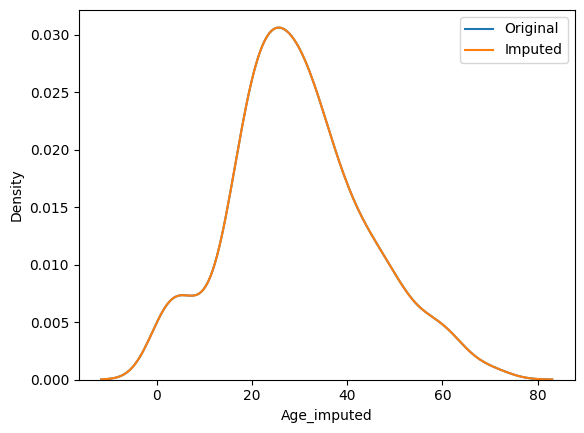

In [35]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [36]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  204.34951339046142


In [37]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,71.512440
Age,71.512440,204.349513,204.349513
Age_imputed,71.512440,204.349513,204.349513


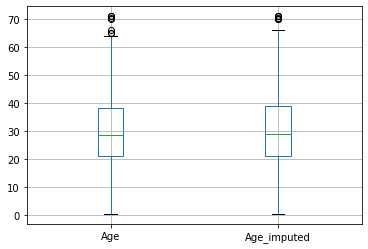

In [ ]:
X_train[['Age', 'Age_imputed']].boxplot()
# 2. .boxplot()
# Creates a statistical visualization called a boxplot.
# A boxplot shows:
# | Feature   | Meaning        |
# | --------- | -------------- |
# | Minimum   | smallest value |
# | Maximum   | largest value  |
# | Median    | middle value   |
# | Quartiles | spread of data |
# | Outliers  | unusual values |


In [ ]:
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))
# same  fare inputs value ke liye same  random  age value milega, isse randomness bhi preserve hogi aur same fare ke liye same age milega, jo ki real world me bhi hota hai.

In [ ]:
# This is for categorical data
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [142]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [39]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [43]:
X = data
y = data['SalePrice']

In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [46]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [147]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
989,NaN,TA,197000,TA,NaN
517,TA,TA,265000,TA,TA
910,NaN,TA,154300,TA,NaN
208,Gd,TA,277000,TA,Gd
340,NaN,TA,202900,TA,NaN


In [47]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\856878696.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\856878696.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the 

In [48]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [150]:
temp

,original,imputed
TA,0.951043,0.949486
Fa,0.037171,0.037671
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [49]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.338945
TA,0.412439,0.282828
Fa,0.040917,0.028058
Po,0.027823,0.019080
Ex,0.024550,0.016835


C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6

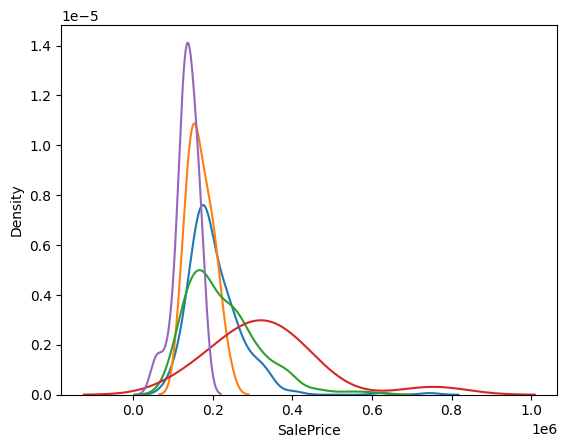

In [50]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\Asus\AppData\Local\Temp\ipykernel_17948\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974

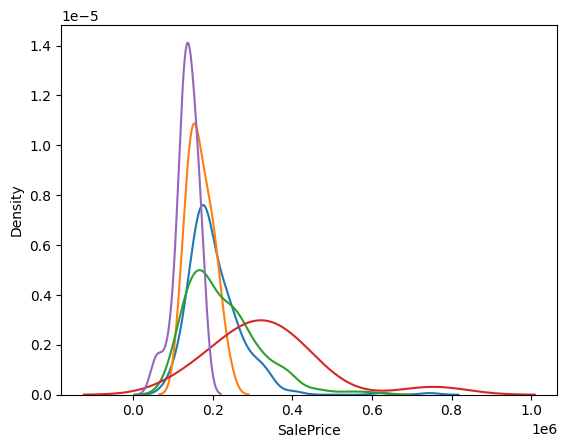

In [ ]:
# here distribution of sale price for different categories of fireplace quality is shown above, now we will see the distribution of sale price for different categories of fireplace quality after imputation. so here we can not use this for linear modeling because linear model ke liye hume continuous variable chahiye, yaha categorical variable hai, isliye hum isse linear model me use nahi kar sakte hai, lekin hum isse tree based model me use kar sakte hai, kyuki tree based model categorical variable ko bhi handle kar leta hai. and here distribution bhi change ho rha hai 
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()